## **Building CNN LSTM Model**

A **CNN-LSTM** is a hybrid deep learning architecture that combines a **Convolutional Neural Network (CNN)** with a **Long Short-Term Memory (LSTM)** network to effectively process data containing both local patterns and temporal dependencies. The CNN component extracts meaningful features from the input data, while the LSTM component learns sequential relationships and long-term dependencies within those features.

Time series classification and forecasting are common tasks in machine learning and deep learning. These tasks involve analyzing sequential data and either predicting future values (forecasting) or assigning a class label to an entire sequence (classification). Examples include stock market prediction, activity recognition, fault detection, weather forecasting, healthcare monitoring, and sensor data analysis.

CNNs and LSTMs are among the most widely used neural network architectures for time series analysis. CNNs excel at learning local patterns and feature representations from raw data, whereas LSTMs are designed to capture temporal dependencies and long-term relationships within sequences. By combining these architectures, CNN-LSTM models can leverage the strengths of both approaches, often leading to improved predictive performance.


CNN-LSTM models combine the feature extraction capabilities of Convolutional Neural Networks with the sequence modeling power of Long Short-Term Memory networks. CNNs efficiently learn local patterns and important features from raw time series data, while LSTMs capture temporal relationships and long-term dependencies. This combination enables CNN-LSTM architectures to deliver strong performance on a wide range of time series classification and forecasting problems.

Whether implemented as a sequential CNN-to-LSTM model, an LSTM-to-CNN model, or a parallel architecture, CNN-LSTM networks provide a flexible and powerful framework for solving real-world sequential data challenges.


In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import optimizers
from keras.utils import plot_model
from keras.models import Sequential, Model
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import Dense, LSTM, RepeatVector, TimeDistributed, Flatten
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
# import plotly.plotly as py
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

%matplotlib inline
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

# Set seeds to make the experiment more reproducible.
import tensorflow as tf
# This sets Python, NumPy, and TensorFlow seeds simultaneously
tf.keras.utils.set_random_seed(1)

#### **1. Load Data**

In [51]:
train = pd.read_csv('../../Datasets/Store Item Demand/train.csv')
test = pd.read_csv('../../Datasets/Store Item Demand/test.csv')

In [52]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

In [53]:
train.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [54]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [55]:
# Time period of the train dataset
print('Min date from train set: %s' % train['date'].min().date())
print('Max date from train set: %s' % train['date'].max().date())

Min date from train set: 2013-01-01
Max date from train set: 2017-12-31


In [56]:
# Let's find out what's the time gap between the last day from training set from the last day of the test set, this will be out lag 
# (the amount of day that need to be forecast)

lag_size = (test['date'].max() - train['date'].max()).days
print('Max date from train set: %s' % train['date'].max().date())
print('Max date from test set: %s' % test['date'].max().date())
print('Forecast lag size', lag_size)

Max date from train set: 2017-12-31
Max date from test set: 2018-03-31
Forecast lag size 90


In [57]:
# Basic EDA: To explore the time series data first we need to aggregate the sales by day

daily_sales = train.groupby('date', as_index=False)['sales'].sum()
store_daily_sales = train.groupby(['store', 'date'], as_index=False)['sales'].sum()
item_daily_sales = train.groupby(['item', 'date'], as_index=False)['sales'].sum()

In [58]:
# Overall Daily Sells

daily_sales_sc = go.Scatter(x=daily_sales['date'], y=daily_sales['sales'])
layout = go.Layout(title='Daily sales', xaxis=dict(title='Date'), yaxis=dict(title='Sales'))
fig = go.Figure(data=[daily_sales_sc], layout=layout)
iplot(fig)

In [59]:
# Daily sales by store

store_daily_sales_sc = []
for store in store_daily_sales['store'].unique():
    current_store_daily_sales = store_daily_sales[(store_daily_sales['store'] == store)]
    store_daily_sales_sc.append(go.Scatter(x=current_store_daily_sales['date'], y=current_store_daily_sales['sales'], name=('Store %s' % store)))

layout = go.Layout(title='Store daily sales', xaxis=dict(title='Date'), yaxis=dict(title='Sales'))
fig = go.Figure(data=store_daily_sales_sc, layout=layout)
iplot(fig)

In [60]:
# Daily sales by item¶

item_daily_sales_sc = []
for item in item_daily_sales['item'].unique():
    current_item_daily_sales = item_daily_sales[(item_daily_sales['item'] == item)]
    item_daily_sales_sc.append(go.Scatter(x=current_item_daily_sales['date'], y=current_item_daily_sales['sales'], name=('Item %s' % item)))

layout = go.Layout(title='Item daily sales', xaxis=dict(title='Date'), yaxis=dict(title='Sales'))
fig = go.Figure(data=item_daily_sales_sc, layout=layout)
iplot(fig)

In [61]:
# Sub-sample train set to get only the last year of data and reduce training time
train = train[(train['date'] >= '2017-01-01')]

In [62]:
# Rearrange dataset so we can apply shift methods
train_gp = train.sort_values('date').groupby(['item', 'store', 'date'], as_index=False)
train_gp = train_gp.agg({'sales':['mean']})
train_gp.columns = ['item', 'store', 'date', 'sales']
train_gp.head()

,item,store,date,sales
0,1,1,2017-01-01,19.0
1,1,1,2017-01-02,15.0
2,1,1,2017-01-03,10.0
3,1,1,2017-01-04,16.0
4,1,1,2017-01-05,14.0


In [63]:
# Transform the data into a time series problem
def series_to_supervised(data, window=1, lag=1, dropnan=True):
    cols, names = list(), list()
    # Input sequence (t-n, ... t-1)
    for i in range(window, 0, -1):
        cols.append(data.shift(i))
        names += [('%s(t-%d)' % (col, i)) for col in data.columns]
    # Current timestep (t=0)
    cols.append(data)
    names += [('%s(t)' % (col)) for col in data.columns]
    # Target timestep (t=lag)
    cols.append(data.shift(-lag))
    names += [('%s(t+%d)' % (col, lag)) for col in data.columns]
    # Put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # Drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [64]:
# We will use the current timestep and the last 29 to forecast 90 days ahead
window = 29
lag = lag_size
series = series_to_supervised(train_gp.drop('date', axis=1), window=window, lag=lag)
series.head()

,item(t-29),store(t-29),sales(t-29),item(t-28),store(t-28),sales(t-28),item(t-27),store(t-27),sales(t-27),item(t-26),...,sales(t-2),item(t-1),store(t-1),sales(t-1),item(t),store(t),sales(t),item(t+90),store(t+90),sales(t+90)
29,1.0,1.0,19.0,1.0,1.0,15.0,1.0,1.0,10.0,1.0,...,16.0,1.0,1.0,24.0,1,1,9.0,1.0,1.0,33.0
30,1.0,1.0,15.0,1.0,1.0,10.0,1.0,1.0,16.0,1.0,...,24.0,1.0,1.0,9.0,1,1,17.0,1.0,1.0,15.0
31,1.0,1.0,10.0,1.0,1.0,16.0,1.0,1.0,14.0,1.0,...,9.0,1.0,1.0,17.0,1,1,15.0,1.0,1.0,21.0
32,1.0,1.0,16.0,1.0,1.0,14.0,1.0,1.0,24.0,1.0,...,17.0,1.0,1.0,15.0,1,1,17.0,1.0,1.0,29.0
33,1.0,1.0,14.0,1.0,1.0,24.0,1.0,1.0,14.0,1.0,...,15.0,1.0,1.0,17.0,1,1,24.0,1.0,1.0,19.0


In [65]:
# Drop rows with different item or store values than the shifted columns
last_item = 'item(t-%d)' % window
last_store = 'store(t-%d)' % window
series = series[(series['store(t)'] == series[last_store])]
series = series[(series['item(t)'] == series[last_item])]

In [66]:
# Remove unwanted columns
columns_to_drop = [('%s(t+%d)' % (col, lag)) for col in ['item', 'store']]
for i in range(window, 0, -1):
    columns_to_drop += [('%s(t-%d)' % (col, i)) for col in ['item', 'store']]
series.drop(columns_to_drop, axis=1, inplace=True)
series.drop(['item(t)', 'store(t)'], axis=1, inplace=True)

In [67]:
# Train/validation split
# Label
labels_col = 'sales(t+%d)' % lag_size
labels = series[labels_col]
series = series.drop(labels_col, axis=1)

X_train, X_valid, Y_train, Y_valid = train_test_split(series, labels.values, test_size=0.4, random_state=0)
print('Train set shape', X_train.shape)
print('Validation set shape', X_valid.shape)
X_train.head()

Train set shape (100746, 30)
Validation set shape (67164, 30)


,sales(t-29),sales(t-28),sales(t-27),sales(t-26),sales(t-25),sales(t-24),sales(t-23),sales(t-22),sales(t-21),sales(t-20),...,sales(t-9),sales(t-8),sales(t-7),sales(t-6),sales(t-5),sales(t-4),sales(t-3),sales(t-2),sales(t-1),sales(t)
18801,97.0,111.0,90.0,115.0,123.0,70.0,99.0,74.0,107.0,108.0,...,85.0,95.0,123.0,109.0,127.0,132.0,87.0,101.0,102.0,114.0
160385,38.0,43.0,43.0,55.0,47.0,51.0,38.0,41.0,37.0,59.0,...,41.0,38.0,38.0,53.0,53.0,45.0,44.0,24.0,30.0,37.0
73123,55.0,45.0,41.0,46.0,47.0,36.0,30.0,46.0,41.0,42.0,...,38.0,36.0,40.0,50.0,44.0,44.0,40.0,38.0,50.0,49.0
90428,139.0,157.0,85.0,99.0,136.0,110.0,121.0,123.0,147.0,91.0,...,130.0,128.0,128.0,95.0,116.0,110.0,117.0,118.0,129.0,132.0
167151,86.0,58.0,88.0,87.0,114.0,113.0,64.0,76.0,87.0,81.0,...,55.0,66.0,59.0,53.0,63.0,59.0,77.0,39.0,56.0,62.0


#### **Prepare Model**

MLP for Time Series Forecasting¶
- First we will use a Multilayer Perceptron model or MLP model, here our model will have input features equal to the window size.
- The thing with MLP models is that the model don't take the input as sequenced data, so for the model, it is just receiving inputs and don't treat them as sequenced data, that may be a problem since the model won't see the data with the sequence patter that it has.
- Input shape [samples, timesteps].

In [68]:
epochs = 40
batch = 256
lr = 0.0003
adam = optimizers.Adam(lr)

E0000 00:00:1790408533.440884  117770 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [69]:
model_mlp = Sequential()
model_mlp.add(Dense(100, activation='relu', input_dim=X_train.shape[1]))
model_mlp.add(Dense(1))
model_mlp.compile(loss='mse', optimizer=adam)
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# Train Model

mlp_history = model_mlp.fit(X_train.values, Y_train, validation_data=(X_valid.values, Y_valid), epochs=epochs, verbose=1)

Epoch 1/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 577us/step - loss: 426.5156 - val_loss: 382.2969
Epoch 2/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 546us/step - loss: 369.3692 - val_loss: 365.0356
Epoch 3/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 538us/step - loss: 358.9585 - val_loss: 359.2819
Epoch 4/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 535us/step - loss: 355.0593 - val_loss: 357.8618
Epoch 5/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 542us/step - loss: 352.8849 - val_loss: 354.3912
Epoch 6/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 519us/step - loss: 351.3792 - val_loss: 352.7932
Epoch 7/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 544us/step - loss: 350.1436 - val_loss: 350.6353
Epoch 8/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 545us/step - loss: 349.0882 - val_loss: 349.3486
Epoch 9/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 513us/step - loss: 348.1060 - val_loss: 349.3993
Epoch 10/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 520us/step - loss: 347.2826 - val_loss: 347.6764
Epoch 11/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 526us/step - 

#### **CNN for Time Series Forecasting**
- For the CNN model we will use one convolutional hidden layer followed by a max pooling layer. The filter maps are then flattened before being interpreted by a Dense layer and outputting a prediction.
- The convolutional layer should be able to identify patterns between the timesteps.
- Input shape [samples, timesteps, features].

##### **Data preprocess**
- Reshape from [samples, timesteps] into [samples, timesteps, features].
- This same reshaped data will be used on the CNN and the LSTM model.

In [71]:
X_train_series = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_valid_series = X_valid.values.reshape((X_valid.shape[0], X_valid.shape[1], 1))
print('Train set shape', X_train_series.shape)
print('Validation set shape', X_valid_series.shape)

Train set shape (100746, 30, 1)
Validation set shape (67164, 30, 1)


In [75]:
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_series.shape[1], X_train_series.shape[2])))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(50, activation='relu'))
model_cnn.add(Dense(1))

model_cnn.compile(loss='mse', optimizer='adam')

model_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 29, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │        44,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,093 (176.14 KB)

 Trainable params: 45,093 (176.14 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
cnn_history = model_cnn.fit(X_train_series, Y_train, validation_data=(X_valid_series, Y_valid), epochs=epochs, verbose=1)

Epoch 1/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 417.4123 - val_loss: 416.7734
Epoch 2/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 387.9539 - val_loss: 388.9122
Epoch 3/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 372.3324 - val_loss: 374.7361
Epoch 4/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 366.9623 - val_loss: 368.6797
Epoch 5/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 364.2974 - val_loss: 364.7318
Epoch 6/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 361.4113 - val_loss: 360.1586
Epoch 7/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 359.5308 - val_loss: 359.1707
Epoch 8/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 357.9537 - val_loss: 356.7473
Epoch 9/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 356.9363 - val_loss: 355.5228
Epoch 10/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 356.2115 - val_loss: 354.9791
Epoch 11/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 355.5936 - val_l

#### **LSTM for Time Series Forecasting**
- Now the LSTM model actually sees the input data as a sequence, so it's able to learn patterns from sequenced data (assuming it exists) better than the other ones, especially patterns from long sequences.
- Input shape [samples, timesteps, features].

In [81]:
from tensorflow.keras.optimizers import Adam

# 1. Define the model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train_series.shape[1], X_train_series.shape[2])))
model_lstm.add(Dense(1))

# 2. CREATE A FRESH OPTIMIZER INSTANCE HERE
fresh_adam = Adam(learning_rate=0.001) 

# 3. Compile with the new optimizer instance
model_lstm.compile(loss='mse', optimizer=fresh_adam)
model_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# 4. Fit the model
lstm_history = model_lstm.fit(X_train_series, Y_train, validation_data=(X_valid_series, Y_valid), epochs=epochs, verbose=1)

Epoch 1/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 503.0388 - val_loss: 383.4281
Epoch 2/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 378.8426 - val_loss: 386.4962
Epoch 3/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 374.7820 - val_loss: 366.6807
Epoch 4/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 903508608.0000 - val_loss: 458.3311
Epoch 5/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 427.7019 - val_loss: 410.1711
Epoch 6/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 405.9147 - val_loss: 390.0451
Epoch 7/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 417.3087 - val_loss: 400.7709
Epoch 8/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 424.3055 - val_loss: 441.3172
Epoch 9/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 414.7566 - val_loss: 406.6834
Epoch 10/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 410.1880 - val_loss: 397.7989
Epoch 11/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4

#### **CNN-LSTM for Time Series Forecasting**
- Input shape [samples, subsequences, timesteps, features].

In [83]:
subsequences = 2
timesteps = X_train_series.shape[1]//subsequences
X_train_series_sub = X_train_series.reshape((X_train_series.shape[0], subsequences, timesteps, 1))
X_valid_series_sub = X_valid_series.reshape((X_valid_series.shape[0], subsequences, timesteps, 1))
print('Train set shape', X_train_series_sub.shape)
print('Validation set shape', X_valid_series_sub.shape)

Train set shape (100746, 2, 15, 1)
Validation set shape (67164, 2, 15, 1)


In [86]:
model_cnn_lstm = Sequential()
model_cnn_lstm.add(TimeDistributed(Conv1D(filters=64, kernel_size=1, activation='relu'), 
                                   input_shape=(None, X_train_series_sub.shape[2], X_train_series_sub.shape[3])))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(pool_size=2)))
model_cnn_lstm.add(TimeDistributed(Flatten()))
model_cnn_lstm.add(LSTM(50, activation='relu'))
model_cnn_lstm.add(Dense(1))

# Compile with the new optimizer instance
model_cnn_lstm.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
model_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [87]:
cnn_lstm_history = model_cnn_lstm.fit(
    X_train_series_sub, Y_train, 
    validation_data=(X_valid_series_sub, Y_valid), 
    epochs=epochs, 
    verbose=1
)

Epoch 1/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 426.6495 - val_loss: 395.7178
Epoch 2/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 396.3391 - val_loss: 385.0935
Epoch 3/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 391.5578 - val_loss: 382.4237
Epoch 4/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 387.8445 - val_loss: 379.4296
Epoch 5/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 385.2830 - val_loss: 377.5255
Epoch 6/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 383.7586 - val_loss: 376.5826
Epoch 7/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 382.5490 - val_loss: 375.2301
Epoch 8/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 381.4752 - val_loss: 374.7712
Epoch 9/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 380.3185 - val_loss: 374.1294
Epoch 10/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 378.8511 - val_loss: 371.7834
Epoch 11/40
3149/3149 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 376.7578 - val_l

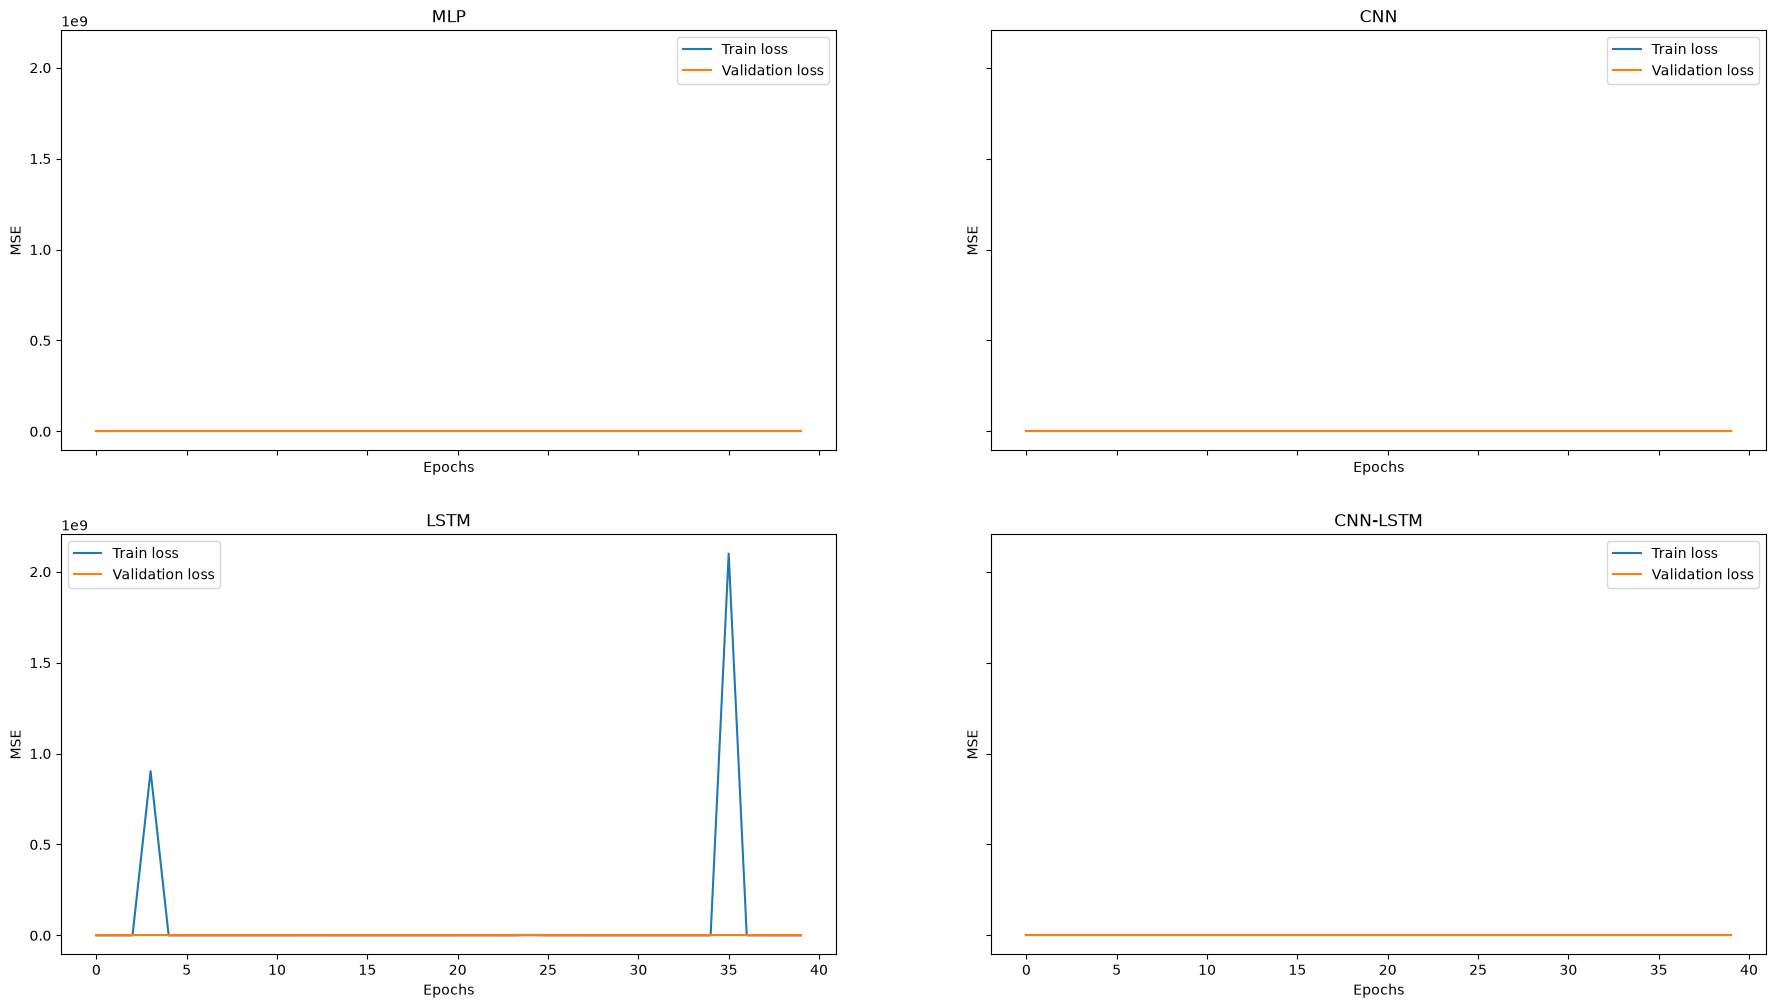

In [88]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True,figsize=(22,12))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

ax1.plot(mlp_history.history['loss'], label='Train loss')
ax1.plot(mlp_history.history['val_loss'], label='Validation loss')
ax1.legend(loc='best')
ax1.set_title('MLP')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE')

ax2.plot(cnn_history.history['loss'], label='Train loss')
ax2.plot(cnn_history.history['val_loss'], label='Validation loss')
ax2.legend(loc='best')
ax2.set_title('CNN')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MSE')

ax3.plot(lstm_history.history['loss'], label='Train loss')
ax3.plot(lstm_history.history['val_loss'], label='Validation loss')
ax3.legend(loc='best')
ax3.set_title('LSTM')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('MSE')

ax4.plot(cnn_lstm_history.history['loss'], label='Train loss')
ax4.plot(cnn_lstm_history.history['val_loss'], label='Validation loss')
ax4.legend(loc='best')
ax4.set_title('CNN-LSTM')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('MSE')

plt.show()

In [89]:
# MLP on train and validation

mlp_train_pred = model_mlp.predict(X_train.values)
mlp_valid_pred = model_mlp.predict(X_valid.values)
print('Train rmse:', np.sqrt(mean_squared_error(Y_train, mlp_train_pred)))
print('Validation rmse:', np.sqrt(mean_squared_error(Y_valid, mlp_valid_pred)))

3149/3149 ━━━━━━━━━━━━━━━━━━━━ 1s 333us/step
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 0s 227us/step
Train rmse: 18.349853063333804
Validation rmse: 18.481321048967875


In [90]:
# CNN on train and validation
cnn_train_pred = model_cnn.predict(X_train_series)
cnn_valid_pred = model_cnn.predict(X_valid_series)
print('Train rmse:', np.sqrt(mean_squared_error(Y_train, cnn_train_pred)))
print('Validation rmse:', np.sqrt(mean_squared_error(Y_valid, cnn_valid_pred)))

3149/3149 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step
Train rmse: 18.659454234700426
Validation rmse: 18.74174225549963


In [91]:
# LSTM on train and validation
lstm_train_pred = model_lstm.predict(X_train_series)
lstm_valid_pred = model_cnn.predict(X_valid_series)
print('Train rmse:', np.sqrt(mean_squared_error(Y_train, lstm_train_pred)))
print('Validation rmse:', np.sqrt(mean_squared_error(Y_valid, lstm_valid_pred)))

3149/3149 ━━━━━━━━━━━━━━━━━━━━ 3s 903us/step
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 1s 468us/step
Train rmse: 23.386218727298253
Validation rmse: 18.74174225549963


In [92]:
# CNN-LSTM on train and validation
cnn_lstm_train_pred = model_cnn_lstm.predict(X_train_series_sub)
cnn_lstm_valid_pred = model_cnn_lstm.predict(X_valid_series_sub)
print('Train rmse:', np.sqrt(mean_squared_error(Y_train, cnn_lstm_train_pred)))
print('Validation rmse:', np.sqrt(mean_squared_error(Y_valid, cnn_lstm_valid_pred)))

3149/3149 ━━━━━━━━━━━━━━━━━━━━ 2s 604us/step
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step
Train rmse: 18.82365854140627
Validation rmse: 18.86768825851367
